In [1]:
using Pkg
Pkg.activate("C:/Users/ibzja/Documents/UPF_2022_2026/4t/2n_trimestre/Practiques_tutelades/CellBasedModels.jl")
using CellBasedModels 
using GeometryBasics
using Distributions
using GLMakie, Colors
Makie.inline!(true)
using CSV, DataFrames, Statistics
using Printf, JLD2
using SpecialFunctions
using LsqFit
using LinearAlgebra

  Activating project at `C:\Users\ibzja\Documents\UPF_2022_2026\4t\2n_trimestre\Practiques_tutelades\CellBasedModels.jl`


In [2]:
function meshgrid(x, y)
    X = repeat(x', length(y), 1)
    Y = repeat(y, 1, length(x))
    return X, Y
end

meshgrid (generic function with 1 method)

In [ ]:
filename = "c_o2_neg_0.5_2.jld2"
steps = 20000
# Get all step keys
# steps = [k for k in keys(jldopen(filename, "r")) if startswith(k, "step_")]
# nsteps = length(steps)
# steped = 1:30000
# nsteps = length(steped)

# Define grid for heatmap (assuming 200x200)
# x_range = range(com.simBox[1,1], com.simBox[1,2], length=200)
# y_range = range(com.simBox[2,1], com.simBox[2,2], length=200)
# x_range = range(-100, 100, length=200)
# y_range = range(-100, 100, length=200)

# Initialize figure
fig = Figure(size = (900, 600))
ax = Axis(fig[1, 1], aspect=1, title = "Step 1")
xs, ys = 0.0, 0.0
len = 200

dark = colorant"#645986"
white = colorant"#FFFFFF"
cmap = cgrad([white, dark])

x_grid = range(-100, 100, length=len)
y_grid = range(-100, 100, length=len)

# X, Y = meshgrid(x_grid, y_grid)

# λ = sqrt(13.33/ 0.03)

# r = sqrt.((X .- xs).^2 .+ (Y .- ys).^2)

# mm_grid = @. 1.0 * besselk(0, r / λ)
bac = colorant"#0E1428"


record(fig, "crypt_o2_neg_n05.mp4", 100:300:steps; framerate=3) do i
    step_key = @sprintf("step_%06d", i)
    println(i)
    jldopen(filename, "r") do file
        if !haskey(file, step_key)
            println("Warning: Key $step_key not found in file.")
            return
        end
        g = file[step_key]

        empty!(ax)
        mm_grid = g["mm_grid"]
        hm = heatmap!(ax, range(0, 500, length=250), range(0, 500, length=250), mm_grid, colormap = cmap)

        # Update scatter (source)
        x = g["x"]
        y = g["y"]


        # Update rods
        theta = g["theta"]
        l = 3

        for i in 1:length(x)
            scatter!(ax, x, y, color = bac, markersize = 4)
        end
    end
end


100
400
700
1000
1300
1600
1900
2200
2500
2800
3100
3400
3700
4000
4300
4600
4900
5200
5500


# Individual bac

In [29]:
fixed_source = ABM(2,
    agent = Dict(
        :vx => Float64,
        :vy => Float64,
        :v => Float64,  #Swimming speed
        :theta => Float64,
        :d => Float64,
        :l => Float64,
        :m => Float64,
        :fx => Float64,
        :fy => Float64,
        :W => Float64,
        :pressure => Float64,
        :active => Bool,

        :methyl => Float64, #Receptor methylation
        :Yp => Float64, #CheYP levels, probability of tumblingç
        :G => Float64,
        :λ => Float64,
        :P => Float64,
        :M => Float64,
        :F => Float64,
        :A => Float64
        
    ),

    model = Dict(

        :Dr_run => Float64,

        :ε0 => Float64, #Energy parameters
        :ε1 => Float64,
        :ε2 => Float64,
        :ε3 => Float64,
        :K => Float64,
        :Nrec => Float64, #Cooperativity
        :Ki => Float64, #Dissociation constants
        :Ka => Float64,
        :τm => Float64, #Methylation adaptation timescale
        :α => Float64,      #Total Yp pool
        :ωFrec => Float64,     #Basal switching frequency
        :Ky => Float64,         #CheA - CheY phosphorylation rate
        :Z => Float64,          #CheZ concentration
        :Kz => Float64,         #CheZ mediated dephosphorylation rate
        :Yy => Float64,         #Basa Yp leak

        :DMedium => Float64,
        :delta => Float64,

        :sigma => Float64, #Gaussian width. 
        :R_source => Float64
    ),

    agentODE = quote  

        # r = sqrt((x)^2 + (y)^2)
        # ll = sqrt(DMedium / delta)

        # # evitar singularidad en r=0
        # r_eff = max(r, 1e-3)

        # mm = 1.0 * besselk(0, r_eff / ll)
        mm = 0.02*exp(x*30^(-2))
        M = mm

        F = ε0 + ε1 * methyl + Nrec * log((1 + mm / Ki) / (1 + mm / Ka)) #Equació del paper per definir activitat del receptor
        F0 = log(((Ky * (α - K)) / (K * (Kz * Z + Yy))) - 1)        #Energia lliure en estat adaptat

        mx = (ε0 + Nrec * log((1 + mm / Ki) / (1 + mm / Ka)) - F0) / (- ε1)

        A = 1 / (1 + exp(F))    

        Yp = (Ky * A * α) / ((Ky * A) + (Kz * Z) + Yy)

        G = ε2 / 4 - (ε3 / 2) / (1 + (K / Yp))      #CheYp segons activitat receptor

        dt(x) = vx 
        dt(y) = vy  
        dt(methyl) = -(1 / τm) * (methyl - mx)        #Methylation
        
    end,

    agentRule = quote

        v_run = v
        v_tumble = 0.25 

        speed = active ? v_run : v_tumble

        Dr_tumble = 6.2      
        Dr_total = active ? Dr_run : Dr_tumble

        if active 
            λ = ωFrec*exp(-G)
            P = 1 - exp(-λ * dt)
                
        else
            λ = ωFrec*exp(G)
            P = 1 - exp(-λ * dt)                  
        end


        if active 
            λrt = ωFrec*exp(-G) 

            P_rt = 1 - exp(-λrt * dt)
            P = rand() 
                                                    #Si rate alta = mes probabilitat de canvi. Per tant, si random number mes petit =  canvi. 
            if P < P_rt             #Si rate alta = mes probabilitat de canvi. Per tant, si random number mes petit =  canvi. 
                active = false
                vx = speed * cos(theta)
                vy = speed * sin(theta)
                theta += sqrt(2 * Dr_total * dt) * randn()           #Tumble = random reorientation
            else     #Si rate baixa 
                active = true
                vx = speed * cos(theta)
                vy = speed * sin(theta)
                theta += sqrt(2 * Dr_total * dt) * randn()       #Keep running, reorientation according to rotational difusion
            end

        else
            λtr = ωFrec*exp(G) 
            P_tr = 1 - exp(-λtr * dt)
            P = rand()

            if P < P_tr
                active = true
                vx = speed * cos(theta)
                vy = speed * sin(theta)
                theta += sqrt(2 * Dr_total * dt) * randn()
            else
                active = false
                vx = speed * cos(theta)
                vy = speed * sin(theta)
                theta += sqrt(2 * Dr_total * dt) * randn()
            end
        end
        
        # xmin, xmax = simBox[1,1], simBox[1,2]
        # ymin, ymax = simBox[2,1], simBox[2,2]

        # if x <= xmin
        #     x = xmin + (xmin - x)
        #     theta = pi - theta
        # elseif x >= xmax
        #     x = xmax + (xmax-x)
        #     theta = pi - theta
        # end

        # if y >= ymax
        #     y = 2*ymax - y
        #     theta = 2*pi - theta
        # elseif y <= ymin
        #     y = 2*ymin - y
        #     theta = 2*pi - theta
        # end
    end,
    
    agentAlg = CBMIntegrators.Heun(),
    mediumAlg=DifferentialEquations.Euler(),
    neighborsAlg=CBMNeighbors.CellLinked(cellEdge=10)
)


PARAMETERS
	x (Float64 agent)
	y (Float64 agent)
	M (Float64 agent)
	d (Float64 agent)
	active (Bool agent)
	v (Float64 agent)
	λ (Float64 agent)
	F (Float64 agent)
	fx (Float64 agent)
	A (Float64 agent)
	methyl (Float64 agent)
	vx (Float64 agent)
	l (Float64 agent)
	m (Float64 agent)
	fy (Float64 agent)
	Yp (Float64 agent)
	P (Float64 agent)
	pressure (Float64 agent)
	vy (Float64 agent)
	W (Float64 agent)
	G (Float64 agent)
	theta (Float64 agent)
	ε1 (Float64 model)
	α (Float64 model)
	Z (Float64 model)
	Dr_run (Float64 model)
	Ka (Float64 model)
	R_source (Float64 model)
	ε3 (Float64 model)
	ε0 (Float64 model)
	DMedium (Float64 model)
	delta (Float64 model)
	Ky (Float64 model)
	Kz (Float64 model)
	K (Float64 model)
	ε2 (Float64 model)
	Nrec (Float64 model)
	sigma (Float64 model)
	τm (Float64 model)
	Yy (Float64 model)
	Ki (Float64 model)
	ωFrec (Float64 model)


UPDATE RULES
agentRule
 begin
    v_run = v
    v_tumble = 0.25
    speed = if active
            v_run
        else
      

In [42]:
com = Community(
    fixed_source,
    N=1,
    dt=0.01,
    simBox = [0.0 20.0; 0.0 20.0],
    NMedium = [10, 10]
)

m = 1/100
g = 1/10000
d = 1

com.Dr_run = 0.062

com.v = 20  #Velocitat bacteries biològica
# com.v = 10.0
# com.v = 5.0
# com.v = 2.5
# com.v = 1
# com.v = 0.1

com.ωFrec = 1.3
com.Ki = 0.0182
com.Ka = 3.0
com.Nrec = 6.0
com.ε0   = 6.0
com.ε1   = -1.0
com.ε2   = 80
com.ε3   = 80

com.τm = 1


com.α   = 6.0

com.K = 2.0 

com.Ky = 100.0
com.Kz = 10.0
com.Z = 5.0
com.Yy = 0.1

com.m = 1.        
com.d = 1.        
com.l = 3;

# Attractant
# com.DMedium = 1.25 # n 8
# com.delta = 0.08
# com.DMedium = 2 # n 5
# com.delta = 0.05
# com.DMedium = 3.33 # n 3
# com.delta = 0.03
# com.DMedium = 20 # n 0.5
# com.delta = 0.005


# Repellant
# com.DMedium_2 = 20
# com.delta_2 = 0.005
# com.DMedium_2 = 1.25 # n 8
# com.delta_2 = 0.08
# com.DMedium_2 = 2 # n 5
# com.delta_2 = 0.05
# com.DMedium_2 = 3.33 # n 3
# com.delta_2 = 0.03

com.x = rand(Uniform(com.simBox[1,:]...),com.N)
com.y = rand(Uniform(com.simBox[2,:]...),com.N)
# com.x = 2.5*sqrt(com.DMedium/com.delta)
# com.y = 2.5*sqrt(com.DMedium/com.delta)
com.theta = rand(Uniform(0,2π),com.N)

com.methyl .= 0.0
com.Yp .= com.K

com.active .= true 

1-element Vector{Bool}:
 1

In [43]:
outfile = "one_bac_v20_tm1.jld2"
steps = 1000

loadToPlatform!(com, preallocateAgents=1)
# com.mm = zeros(Float64, com.NMedium...)

jldopen(outfile, "w") do file

    # -------------------------
    # Main loop
    # -------------------------
    for step in 1:steps
        step!(com)


        stepname = @sprintf("step_%06d", step)
        g = JLD2.Group(file, stepname)

            # Agent-level arrays (length = N)
        g["x"] = copy(com.x)
        g["y"] = copy(com.y)
        g["theta"] = copy(com.theta)
        if step%100 == 0
            println(step)
        end

    end
end


100
200
300
400
500
600
700
800
900
1000


In [13]:
filename = "one_bac_small_vtm.jld2"
steps = 1000

# Initialize figure
fig = Figure(size = (900, 600))
ax = Axis(fig[1, 1], aspect=1, title = "Step 1")
xs, ys = 0.0, 0.0
len = 20

bac = colorant"#0E1428"

record(fig, "one_bac_small_vtm.mp4", 1:10:steps; framerate=3) do i
    step_key = @sprintf("step_%06d", i)
    println(i)
    jldopen(filename, "r") do file
        if !haskey(file, step_key)
            println("Warning: Key $step_key not found in file.")
            return
        end
        g = file[step_key]
        empty!(ax)
        # Update scatter (source)
        x = g["x"]
        y = g["y"]


        # Update rods
        theta = g["theta"]
        l = 3

        for i in 1:length(x)
            scatter!(ax, x, y, color = bac, markersize = 4)
        end
    end
end


1
11
21
31
41
51
61
71
81
91
101
111
121
131
141
151
161
171
181
191
201
211
221
231
241
251
261
271
281
291
301
311
321
331
341
351
361
371
381
391
401
411
421
431
441
451
461
471
481
491
501
511
521
531
541
551
561
571
581
591
601
611
621
631
641
651
661
671
681
691
701
711
721
731
741
751
761
771
781
791
801
811
821
831
841
851
861
871
881
891
901
911
921
931
941
951
961
971
981
991


"one_bac_small_vtm.mp4"

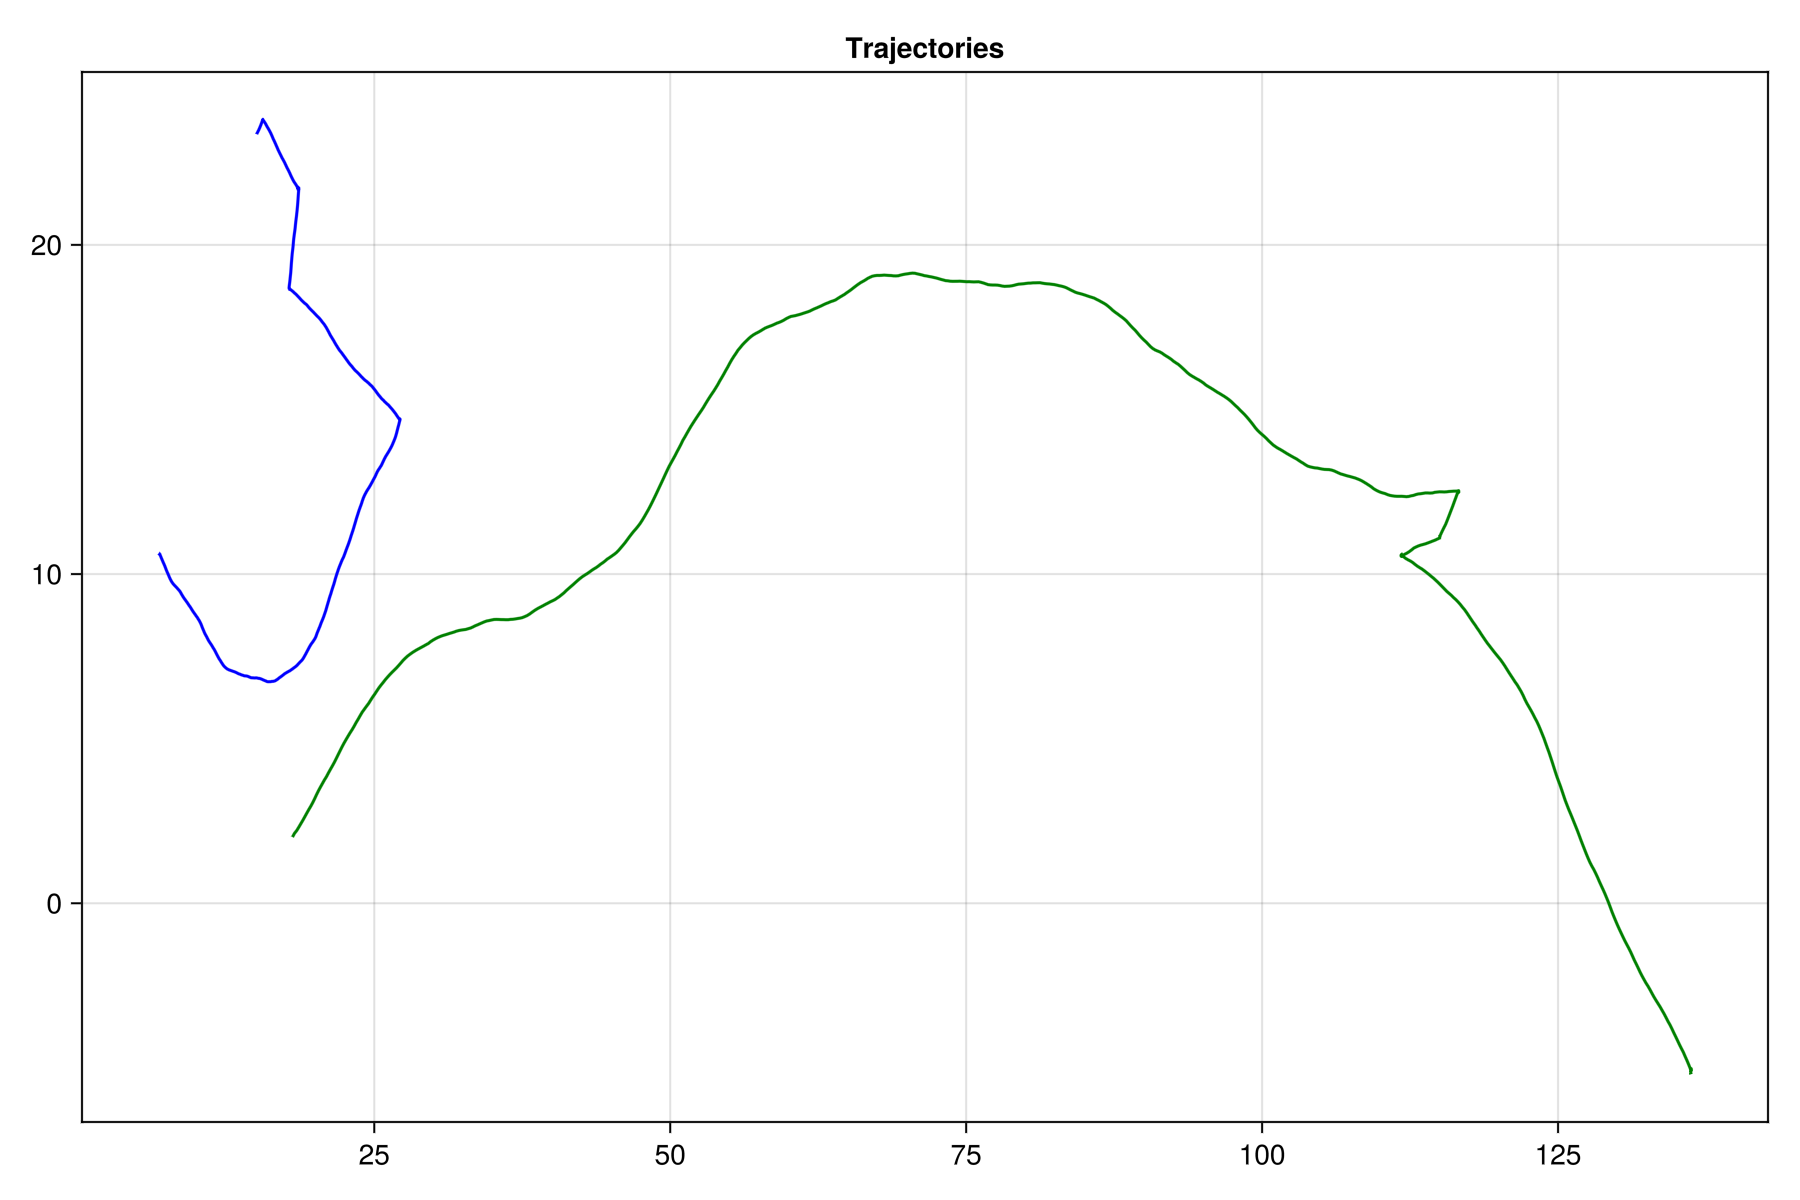

GLMakie.Screen(...)

In [44]:
fig1 = Figure(size = (900,600))
ax1 = Axis(fig1[1,1], title = "Trajectories")

agent = 1    #Trajectory of this agent
traj_x = Vector{Float64}(undef, steps)
traj_y = Vector{Float64}(undef, steps)
traj_x_2 = Vector{Float64}(undef, steps)
traj_y_2 = Vector{Float64}(undef, steps)
jldopen("one_bac_v20_tm1.jld2", "r") do file 
    for step in 1:steps
        g = file[@sprintf("step_%06d", step)]
        traj_x[step] = g["x"][agent]
        traj_y[step] = g["y"][agent]

    end
end


jldopen("one_bac_v5_tm1.jld2", "r") do file 
    for step in 1:steps
        g = file[@sprintf("step_%06d", step)]
        traj_x_2[step] = g["x"][agent]
        traj_y_2[step] = g["y"][agent]

    end
end

lines!(ax1, traj_x, traj_y, color = :green, label = "tm 10")
lines!(ax1, traj_x_2, traj_y_2, color = :blue, label = "tm 1")
display(fig1)